# 🛡️ DESCRIPTION DU PROJET - DÉTECTION SYN FLOOD

## 📌 QU'EST-CE QUE C'EST ?

Ce projet a pour objectif de **détecter les attaques SYN Flood** dans le trafic réseau en utilisant des techniques de **machine learning**.

Il s'agit d’un problème de **classification supervisée binaire** où la variable cible est binaire :
- **Bénin** (trafic normal)
- **Attaque** (SYN Flood DDoS)

Une bonne performance sera caractérisée par une **précision élevée (Precision)** et un **rappel élevé (Recall)**, indiquant que le modèle détecte correctement les attaques tout en minimisant les faux positifs.

L’approche consiste à analyser les flux réseau, appliquer un prétraitement adapté, équilibrer les classes, sélectionner les caractéristiques pertinentes et comparer plusieurs modèles de machine learning.

---

**Dataset** : CICDDoS2019 (Canadian Institute for Cybersecurity)
- Source : Université du Nouveau-Brunswick
- Observations : **50+ millions** de flux réseau
- Période : 2019
- Attaques couvertes : 12 types (SYN, UDP, NTP, DNS, LDAP, etc.)
- Trafic bénin inclus

---

## 🎯 OBJECTIFS

### Objectif Principal
Développer un modèle de **machine learning** capable de :
1. ✅ Détecter les attaques SYN Flood avec une **faible latence**
2. ✅ Identifier les **caractéristiques réseau** les plus discriminantes
3. ✅ Fournir un système **déployable** en temps réel
4. ✅ Comparer plusieurs algorithmes pour trouver le meilleur compromis


## 🧠 APPROCHE ET INTUITIONS

### Hypothèses Métier

**1. Comportement SYN Flood**
- Le ratio **SYN/ACK** augmente anormalement
- Nombre de **paquets par seconde** explose
- Connexions **incomplètes** (half-open)
- **Volume de trafic** anormalement élevé

**2. Caractéristiques Discriminantes**
- `flow_duration` : durée des flux (très courte pour SYN Flood)
- `fwd_packets/sec` : taux de paquets élevé
- `bwd_packets/sec` : faible (peu de réponses)
- `flow_bytes/sec` : volume élevé
- `fwd_psh_flags` : anormalement élevé
- `tcp_window_size` : caractéristique des attaques

**3. Comportement Observable**
- Plus de **requêtes SYN** que de réponses SYN-ACK
- **Pas de handshake** TCP complet (3-way handshake)
- **Différentes adresses IP** sources (spoofing)
- **Ports** souvent aléatoires ou connus (80, 443, 22)

**4. Patterns Temporels**
- Attaques **par vagues** (bursts)
- **Périodicité** dans les pics de trafic
- Variation **soudaine** du débit


## ⚠️ DIFFICULTÉS RENCONTRÉES

Difficultés rencontrées
Plusieurs difficultés ont été identifiées :

Valeurs infinies : 202 317 valeurs infinies dans Flow Bytes/s et Flow Packets/s dues à des flux de durée zéro (division par zéro dans CICFlowMeter)
Déséquilibre extrême : 1 582 289 attaques vs seulement 56 863 BENIGN dans le dataset complet
Résultats contre-intuitifs : ACK Flag Count = 1 pour les attaques car CICFlowMeter est côté serveur victime
Corrélations redondantes : 26 variables sur 65 avaient une corrélation > 0.95 entre elles

---

## 🛠️ PRÉTRAITEMENT DES DONNÉES

### Opérations Effectuées

1. **Nettoyage**
   - Suppression des colonnes non informatives (IP, ID, timestamps)
   - Correction des valeurs négatives (abs)
   - Remplacement des valeurs infinies par 

2. **Réduction de Dimension**
   - Suppression des colonnes à variance nulle/faible
   - Suppression des colonnes fortement corrélées 

3. **Équilibrage**
   - **Undersampling** (contrainte mémoire)
   - **Binary-balanced** : 50% attaques / 50% bénin


4. **Standardisation**
   - StandardScaler pour les modèles sensibles
   - MinMaxScaler alternative

### 🔍 Résultats des Prétraitements

- Réduction de **80** à **~30** caractéristiques
- **Pielou Index** = 1.0 (parfaitement équilibré)
- Pas de data leakage (FS dans CV)
- Temps d'entraînement réduit significativement

---

## 🔬 SÉLECTION DE CARACTÉRISTIQUES

### Méthodes Indépendantes de la Cible
- **Filtres** : Suppression basse variance, corrélation
- **PCC Matrix** : Élimination des variables redondantes

### Méthodes Dépendantes de la Cible

### Métriques de Sélection
- **Rang** de chaque caractéristique
- **Importance** des variables
- **Performance** en fonction du nombre K de features

---

## 📊 MODÈLES TESTÉS



# IMPORT DES LIBRAIRIES

In [151]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             classification_report, confusion_matrix)
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    HistGradientBoostingClassifier
)


from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (Dense, Dropout, Flatten, Conv1D,
                                     MaxPooling1D, LSTM, BatchNormalization)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.optimizers.schedules import ExponentialDecay
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.image as mpimg

print("Imports OK")

Imports OK


# CHARGEMENT DES DONNÉES ET DESCRIPTION DES DONNÉES

In [172]:
# CHARGEMENT ET APERÇU DES DONNÉES
fichier = 'E:/01-12/Syn.csv'
df = pd.read_csv(fichier)
df

,Unnamed: 0,Flow ID,Source IP,Source Port,Destination IP,Destination Port,Protocol,Timestamp,Flow Duration,Total Fwd Packets,...,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,SimillarHTTP,Inbound,Label
0,281052,172.16.0.5-192.168.50.1-53058-53058-6,172.16.0.5,53058,192.168.50.1,53058,6,2018-12-01 13:30:30.741451,115799309,19,...,646237.48,1709809.00,1.00,14261168.50,3220326.16,21714933.00,11043464.00,0,1,Syn
1,450424,172.16.0.5-192.168.50.1-32237-32237-6,172.16.0.5,32237,192.168.50.1,32237,6,2018-12-01 13:30:30.741452,113973933,16,...,19.60,49.00,1.00,16281982.71,2573891.02,20019405.00,11993631.00,0,1,Syn
2,182979,172.16.0.5-192.168.50.1-60495-9840-6,172.16.0.5,60495,192.168.50.1,9840,6,2018-12-01 13:30:30.741501,112,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn
3,41540,172.16.0.5-192.168.50.1-59724-59724-6,172.16.0.5,59724,192.168.50.1,59724,6,2018-12-01 13:30:30.741563,105985004,16,...,17.71,48.00,1.00,15140706.86,3077366.46,20954123.00,11120336.00,0,1,Syn
4,358711,172.16.0.5-192.168.50.1-60496-32538-6,172.16.0.5,60496,192.168.50.1,32538,6,2018-12-01 13:30:30.741565,1,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1582676,432793,172.16.0.5-192.168.50.1-43299-42563-6,172.16.0.5,43299,192.168.50.1,42563,6,2018-12-01 13:34:27.402384,1,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn
1582677,514566,172.16.0.5-192.168.50.1-43300-58948-6,172.16.0.5,43300,192.168.50.1,58948,6,2018-12-01 13:34:27.402386,1,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn
1582678,147509,172.16.0.5-192.168.50.1-43301-52300-6,172.16.0.5,43301,192.168.50.1,52300,6,2018-12-01 13:34:27.402451,1,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn
1582679,46401,172.16.0.5-192.168.50.1-43302-40846-6,172.16.0.5,43302,192.168.50.1,40846,6,2018-12-01 13:34:27.403142,1,2,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0,1,Syn


In [153]:
df.shape

(1582681, 88)

In [173]:
col_name = {
'Flow ID': 'Flow ID',
'Source IP': 'Source IP',
'Src IP':  'Source IP',
'Source Port': 'Source Port',
'Src Port': 'Source Port',
'Destination IP': 'Destination IP',
'Dst IP': 'Destination IP',
'Destination Port': 'Destination Port',
'Dst Port': 'Destination Port',
'Protocol': 'Protocol',
'Timestamp': 'Timestamp',
'Flow Duration': 'Flow Duration',
'Total Fwd Packets': 'Total Fwd Packets',
'Tot Fwd Pkts': 'Total Fwd Packets',
'Total Backward Packets': 'Total Backward Packets',
'Tot Bwd Pkts': 'Total Backward Packets',
'Total Length of Fwd Packets': 'Fwd Packets Length Total',
'TotLen Fwd Pkts': 'Fwd Packets Length Total',
'Total Length of Bwd Packets': 'Bwd Packets Length Total',
'TotLen Bwd Pkts': 'Bwd Packets Length Total',
'Fwd Packet Length Max': 'Fwd Packet Length Max',
'Fwd Pkt Len Max': 'Fwd Packet Length Max',
'Fwd Packet Length Min': 'Fwd Packet Length Min',
'Fwd Pkt Len Min': 'Fwd Packet Length Min',
'Fwd Packet Length Mean': 'Fwd Packet Length Mean',
'Fwd Pkt Len Mean': 'Fwd Packet Length Mean',
'Fwd Packet Length Std': 'Fwd Packet Length Std',
'Fwd Pkt Len Std': 'Fwd Packet Length Std',
'Bwd Packet Length Max': 'Bwd Packet Length Max',
'Bwd Pkt Len Max': 'Bwd Packet Length Max',
'Bwd Packet Length Min': 'Bwd Packet Length Min',
'Bwd Pkt Len Min': 'Bwd Packet Length Min',
'Bwd Packet Length Mean': 'Bwd Packet Length Mean',
'Bwd Pkt Len Mean': 'Bwd Packet Length Mean',
'Bwd Packet Length Std': 'Bwd Packet Length Std',
'Bwd Pkt Len Std': 'Bwd Packet Length Std',
'Flow Bytes/s': 'Flow Bytes/s',
'Flow Byts/s': 'Flow Bytes/s',
'Flow Packets/s': 'Flow Packets/s',
'Flow Pkts/s': 'Flow Packets/s',
'Flow IAT Mean': 'Flow IAT Mean',
'Flow IAT Std': 'Flow IAT Std',
'Flow IAT Max': 'Flow IAT Max',
'Flow IAT Min': 'Flow IAT Min',
'Fwd IAT Total': 'Fwd IAT Total',
'Fwd IAT Tot': 'Fwd IAT Total',
'Fwd IAT Mean': 'Fwd IAT Mean',
'Fwd IAT Std': 'Fwd IAT Std',
'Fwd IAT Max': 'Fwd IAT Max',
'Fwd IAT Min': 'Fwd IAT Min',
'Bwd IAT Total': 'Bwd IAT Total',
'Bwd IAT Tot': 'Bwd IAT Total',
'Bwd IAT Mean': 'Bwd IAT Mean',
'Bwd IAT Std': 'Bwd IAT Std',
'Bwd IAT Max': 'Bwd IAT Max',
'Bwd IAT Min': 'Bwd IAT Min',
'Fwd PSH Flags': 'Fwd PSH Flags',
'Bwd PSH Flags': 'Bwd PSH Flags',
'Fwd URG Flags': 'Fwd URG Flags',
'Bwd URG Flags': 'Bwd URG Flags',
'Fwd Header Length': 'Fwd Header Length',
'Fwd Header Len': 'Fwd Header Length',
'Bwd Header Length': 'Bwd Header Length',
'Bwd Header Len': 'Bwd Header Length',
'Fwd Packets/s': 'Fwd Packets/s',
'Fwd Pkts/s': 'Fwd Packets/s',
'Bwd Packets/s': 'Bwd Packets/s',
'Bwd Pkts/s': 'Bwd Packets/s',
'Min Packet Length': 'Packet Length Min',
'Pkt Len Min': 'Packet Length Min',
'Max Packet Length': 'Packet Length Max',
'Pkt Len Max': 'Packet Length Max',
'Packet Length Mean': 'Packet Length Mean',
'Pkt Len Mean': 'Packet Length Mean',
'Packet Length Std': 'Packet Length Std',
'Pkt Len Std': 'Packet Length Std',
'Packet Length Variance': 'Packet Length Variance',
'Pkt Len Var': 'Packet Length Variance',
'FIN Flag Count': 'FIN Flag Count',
'FIN Flag Cnt': 'FIN Flag Count',
'SYN Flag Count': 'SYN Flag Count',
'SYN Flag Cnt': 'SYN Flag Count',
'RST Flag Count': 'RST Flag Count',
'RST Flag Cnt': 'RST Flag Count',
'PSH Flag Count': 'PSH Flag Count',
'PSH Flag Cnt': 'PSH Flag Count',
'ACK Flag Count': 'ACK Flag Count',
'ACK Flag Cnt': 'ACK Flag Count',
'URG Flag Count': 'URG Flag Count',
'URG Flag Cnt': 'URG Flag Count',
'CWE Flag Count': 'CWE Flag Count',
'CWE Flag Cnt': 'CWE Flag Count',
'ECE Flag Count': 'ECE Flag Count',
'ECE Flag Cnt': 'ECE Flag Count',
'Down/Up Ratio': 'Down/Up Ratio',
'Average Packet Size': 'Avg Packet Size',
'Pkt Size Avg': 'Avg Packet Size',
'Avg Fwd Segment Size': 'Avg Fwd Segment Size',
'Fwd Seg Size Avg': 'Avg Fwd Segment Size',
'Avg Bwd Segment Size': 'Avg Bwd Segment Size',
'Bwd Seg Size Avg': 'Avg Bwd Segment Size',
'Fwd Avg Bytes/Bulk': 'Fwd Avg Bytes/Bulk',
'Fwd Byts/b Avg': 'Fwd Avg Bytes/Bulk',
'Fwd Avg Packets/Bulk': 'Fwd Avg Packets/Bulk',
'Fwd Pkts/b Avg': 'Fwd Avg Packets/Bulk',
'Fwd Avg Bulk Rate': 'Fwd Avg Bulk Rate',
'Fwd Blk Rate Avg': 'Fwd Avg Bulk Rate',
'Bwd Avg Bytes/Bulk': 'Bwd Avg Bytes/Bulk',
'Bwd Byts/b Avg': 'Bwd Avg Bytes/Bulk',
'Bwd Avg Packets/Bulk': 'Bwd Avg Packets/Bulk',
'Bwd Pkts/b Avg': 'Bwd Avg Packets/Bulk',
'Bwd Avg Bulk Rate': 'Bwd Avg Bulk Rate',
'Bwd Blk Rate Avg': 'Bwd Avg Bulk Rate',
'Subflow Fwd Packets': 'Subflow Fwd Packets',
'Subflow Fwd Pkts': 'Subflow Fwd Packets',
'Subflow Fwd Bytes': 'Subflow Fwd Bytes',
'Subflow Fwd Byts': 'Subflow Fwd Bytes',
'Subflow Bwd Packets': 'Subflow Bwd Packets',
'Subflow Bwd Pkts': 'Subflow Bwd Packets',
'Subflow Bwd Bytes': 'Subflow Bwd Bytes',
'Subflow Bwd Byts': 'Subflow Bwd Bytes',
'Init_Win_bytes_forward': 'Init Fwd Win Bytes',
'Init Fwd Win Byts': 'Init Fwd Win Bytes',
'Init_Win_bytes_backward': 'Init Bwd Win Bytes',
'Init Bwd Win Byts': 'Init Bwd Win Bytes',
'act_data_pkt_fwd': 'Fwd Act Data Packets',
'Fwd Act Data Pkts': 'Fwd Act Data Packets',
'min_seg_size_forward': 'Fwd Seg Size Min',
'Fwd Seg Size Min': 'Fwd Seg Size Min',
'Active Mean': 'Active Mean',
'Active Std': 'Active Std',
'Active Max': 'Active Max',
'Active Min': 'Active Min',
'Idle Mean': 'Idle Mean',
'Idle Std': 'Idle Std',
'Idle Max': 'Idle Max',
'Idle Min': 'Idle Min',
'Label': 'Label'
}

df.columns = df.columns.str.strip()
df.rename(columns=col_name, inplace=True)

In [155]:
print(df['Label'].unique())

<StringArray>
['Syn', 'BENIGN']
Length: 2, dtype: str


## ANALYSE DE LA VARIABLE CIBLE (Label (syn et Benign))

In [156]:
print("\nDistribution :")
print(df['Label'].value_counts())


Distribution :
Label
Syn       1582289
BENIGN        392
Name: count, dtype: int64


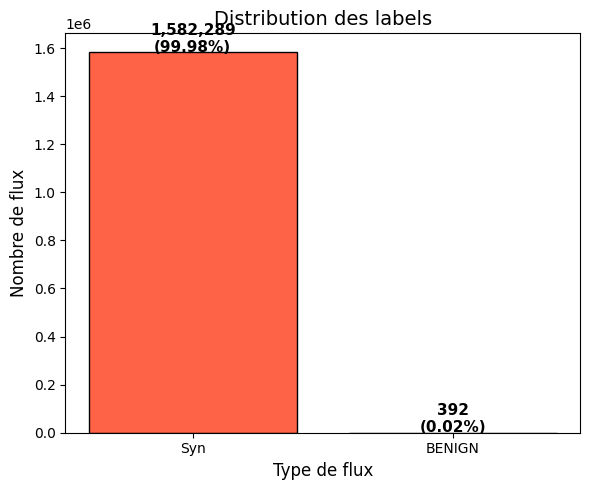

In [157]:
label_counts = df['Label'].value_counts()
plt.figure(figsize=(6, 5))
bars = plt.bar(label_counts.index, label_counts.values,
               color=['tomato', 'steelblue'], edgecolor='black')

plt.title('Distribution des labels', fontsize=14)
plt.xlabel('Type de flux', fontsize=12)
plt.ylabel('Nombre de flux', fontsize=12)

# Ajouter les valeurs sur les barres
for bar, label, count in zip(bars, label_counts.index, label_counts.values):
    pct = (count / len(df)) * 100
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1000,
             f'{count:,}\n({pct:.2f}%)', ha='center', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('label_distribution.png', dpi=150)
plt.show()

In [158]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1582681 entries, 0 to 1582680
Data columns (total 88 columns):
 #   Column                    Non-Null Count    Dtype  
---  ------                    --------------    -----  
 0   Unnamed: 0                1582681 non-null  int64  
 1   Flow ID                   1582681 non-null  str    
 2   Source IP                 1582681 non-null  str    
 3   Source Port               1582681 non-null  int64  
 4   Destination IP            1582681 non-null  str    
 5   Destination Port          1582681 non-null  int64  
 6   Protocol                  1582681 non-null  int64  
 7   Timestamp                 1582681 non-null  str    
 8   Flow Duration             1582681 non-null  int64  
 9   Total Fwd Packets         1582681 non-null  int64  
 10  Total Backward Packets    1582681 non-null  int64  
 11  Fwd Packets Length Total  1582681 non-null  float64
 12  Bwd Packets Length Total  1582681 non-null  float64
 13  Fwd Packet Length Max     1582681 non-

# Description des 88 variables du dataset 

| # | Variable | Signification |
|---|----------|---------------|
| 0 | Unnamed: 0 | Index / Numéro de ligne |
| 1 | Flow ID | Identifiant unique du flux réseau |
| 2 | Source IP | Adresse IP source |
| 3 | Source Port | Port source |
| 4 | Destination IP | Adresse IP de destination |
| 5 | Destination Port | Port de destination |
| 6 | Protocol | Protocole (ICMP, TCP, UDP) |
| 7 | Timestamp | Horodatage du début du flux |
| 8 | Flow Duration | Durée totale du flux (microsecondes) |
| 9 | Total Fwd Packets | Nombre total de paquets envoyés |
| 10 | Total Backward Packets | Nombre total de paquets reçus |
| 11 | Total Length of Fwd Packets | Taille totale des paquets envoyés (octets) |
| 12 | Total Length of Bwd Packets | Taille totale des paquets reçus (octets) |
| 13 | Fwd Packet Length Max | Taille max d'un paquet envoyé |
| 14 | Fwd Packet Length Min | Taille min d'un paquet envoyé |
| 15 | Fwd Packet Length Mean | Taille moyenne des paquets envoyés |
| 16 | Fwd Packet Length Std | Écart-type des tailles des paquets envoyés |
| 17 | Bwd Packet Length Max | Taille max d'un paquet reçu |
| 18 | Bwd Packet Length Min | Taille min d'un paquet reçu |
| 19 | Bwd Packet Length Mean | Taille moyenne des paquets reçus |
| 20 | Bwd Packet Length Std | Écart-type des tailles des paquets reçus |
| 21 | Flow Bytes/s | Débit en octets par seconde |
| 22 | Flow Packets/s | Débit en paquets par seconde |
| 23 | Flow IAT Mean | Temps moyen entre deux paquets du flux |
| 24 | Flow IAT Std | Écart-type des temps inter-paquets |
| 25 | Flow IAT Max | Temps maximum entre deux paquets |
| 26 | Flow IAT Min | Temps minimum entre deux paquets |
| 27 | Fwd IAT Total | Somme des temps entre paquets envoyés |
| 28 | Fwd IAT Mean | Temps moyen entre deux envois |
| 29 | Fwd IAT Std | Écart-type des temps entre envois |
| 30 | Fwd IAT Max | Temps maximum entre deux envois |
| 31 | Fwd IAT Min | Temps minimum entre deux envois |
| 32 | Bwd IAT Total | Somme des temps entre paquets reçus |
| 33 | Bwd IAT Mean | Temps moyen entre deux réceptions |
| 34 | Bwd IAT Std | Écart-type des temps entre réceptions |
| 35 | Bwd IAT Max | Temps maximum entre deux réceptions |
| 36 | Bwd IAT Min | Temps minimum entre deux réceptions |
| 37 | Fwd PSH Flags | Nombre de paquets avec flag PSH (sens aller) |
| 38 | Bwd PSH Flags | Nombre de paquets avec flag PSH (sens retour) |
| 39 | Fwd URG Flags | Nombre de paquets avec flag URG (sens aller) |
| 40 | Bwd URG Flags | Nombre de paquets avec flag URG (sens retour) |
| 41 | Fwd Header Length | Longueur des en-têtes des paquets envoyés (octets) |
| 42 | Bwd Header Length | Longueur des en-têtes des paquets reçus (octets) |
| 43 | Fwd Packets/s | Nombre de paquets envoyés par seconde |
| 44 | Bwd Packets/s | Nombre de paquets reçus par seconde |
| 45 | Min Packet Length | Taille minimale des paquets du flux |
| 46 | Max Packet Length | Taille maximale des paquets du flux |
| 47 | Packet Length Mean | Taille moyenne des paquets du flux |
| 48 | Packet Length Std | Écart-type des tailles des paquets |
| 49 | Packet Length Variance | Variance des tailles des paquets |
| 50 | FIN Flag Count | Nombre de paquets avec flag FIN |
| 51 | SYN Flag Count | Nombre de paquets avec flag SYN |
| 52 | RST Flag Count | Nombre de paquets avec flag RST |
| 53 | PSH Flag Count | Nombre de paquets avec flag PSH |
| 54 | ACK Flag Count | Nombre de paquets avec flag ACK |
| 55 | URG Flag Count | Nombre de paquets avec flag URG |
| 56 | CWE Flag Count | Nombre de paquets avec flag CWE |
| 57 | ECE Flag Count | Nombre de paquets avec flag ECE |
| 58 | Down/Up Ratio | Ratio paquets descendants / montants |
| 59 | Average Packet Size | Taille moyenne des paquets du flux |
| 60 | Avg Fwd Segment Size | Taille moyenne des segments (sens aller) |
| 61 | Avg Bwd Segment Size | Taille moyenne des segments (sens retour) |
| 62 | Fwd Header Length.1 | Duplicata de #41 |
| 63 | Fwd Avg Bytes/Bulk | Moyenne des octets par rafale (sens aller) |
| 64 | Fwd Avg Packets/Bulk | Moyenne des paquets par rafale (sens aller) |
| 65 | Fwd Avg Bulk Rate | Taux moyen des rafales (sens aller) |
| 66 | Bwd Avg Bytes/Bulk | Moyenne des octets par rafale (sens retour) |
| 67 | Bwd Avg Packets/Bulk | Moyenne des paquets par rafale (sens retour) |
| 68 | Bwd Avg Bulk Rate | Taux moyen des rafales (sens retour) |
| 69 | Subflow Fwd Packets | Paquets forward dans une sous-partie du flux |
| 70 | Subflow Fwd Bytes | Octets forward dans une sous-partie du flux |
| 71 | Subflow Bwd Packets | Paquets backward dans une sous-partie du flux |
| 72 | Subflow Bwd Bytes | Octets backward dans une sous-partie du flux |
| 73 | Init_Win_bytes_forward | Taille initiale de la fenêtre TCP (sens aller) |
| 74 | Init_Win_bytes_backward | Taille initiale de la fenêtre TCP (sens retour) |
| 75 | act_data_pkt_fwd | Paquets avec données actives (sens aller) |
| 76 | min_seg_size_forward | Taille minimale des segments TCP (sens aller) |
| 77 | Active Mean | Moyenne des périodes actives du flux |
| 78 | Active Std | Écart-type des périodes actives |
| 79 | Active Max | Période active maximale |
| 80 | Active Min | Période active minimale |
| 81 | Idle Mean | Moyenne des périodes d'inactivité |
| 82 | Idle Std | Écart-type des périodes d'inactivité |
| 83 | Idle Max | Période d'inactivité maximale |
| 84 | Idle Min | Période d'inactivité minimale |
| 85 | SimillarHTTP | Indique si le flux ressemble à du trafic HTTP (0/1) |
| 86 | Inbound | Sens du flux (1=entrant, 0=sortant) |
| 87 | Label | Classe du trafic (BENIGN ou type d'attaque DDoS) |

In [159]:
#enleve les space au debut des variables
df.columns = df.columns.str.strip()

# Supprimer colonnes inutiles 


In [174]:
unique_counts = df.nunique().sort_values(ascending=False)
for col, count in unique_counts.items():
    print()

cols_suppr = [
    "Flow ID",
    'Fwd Header Length.1',
    "Source IP",
    "Source Port",
    "Destination IP",
    "Destination Port",
    "Timestamp",
    "Unnamed: 0",
    "SimillarHTTP",           #  Colonnes d'identification
    "Inbound",                #  capturé de manière incohérente peut fausser le modele
    "Fwd Avg Bytes/Bulk",
    "Fwd Avg Packets/Bulk",
    "Fwd Avg Bulk Rate",
    "Bwd Avg Bytes/Bulk",
    "Bwd Avg Packets/Bulk",
    "Bwd Avg Bulk Rate",      # Colonnes constantes 0
    "Fwd URG Flags",
    "Bwd PSH Flags",
    "Bwd URG Flags",
    "FIN Flag Count",
    "PSH Flag Count",
    "ECE Flag Count"          # Flags toujours à 0
]
df.drop(columns=cols_suppr, inplace=True, errors='ignore')
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

### ETUDE  SYN FLOOD

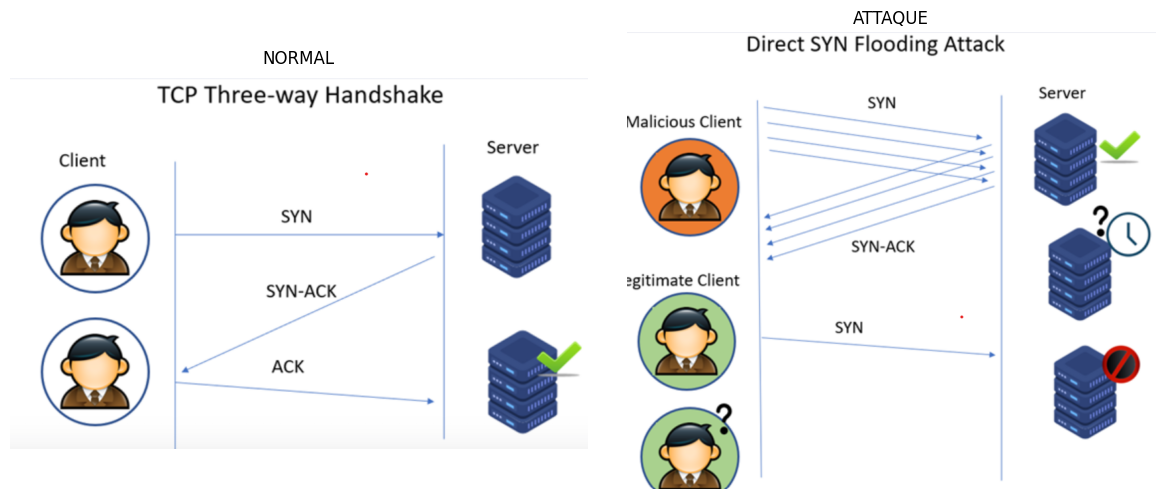

In [161]:
import matplotlib.image as mpimg
# Charger les images
img2 = mpimg.imread('C:/Users/fatou/Downloads/ATTAQUE.png')
img1 = mpimg.imread('C:/Users/fatou/Downloads/NORMAL.png')

# Afficher côte à côte
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(img1)
axes[0].set_title('NORMAL')
axes[0].axis('off')

axes[1].imshow(img2)
axes[1].set_title('ATTAQUE')
axes[1].axis('off')

plt.tight_layout()
plt.show()

# Distribution des variables SYN ET ACK par Classe

         SYN Flag Count  ACK Flag Count
Classe                                 
ATTAQUE            0.00            1.00
BENIGN             0.01            0.15
         SYN Flag Count  ACK Flag Count
Classe                                 
ATTAQUE            0.00            1.00
BENIGN             0.01            0.15


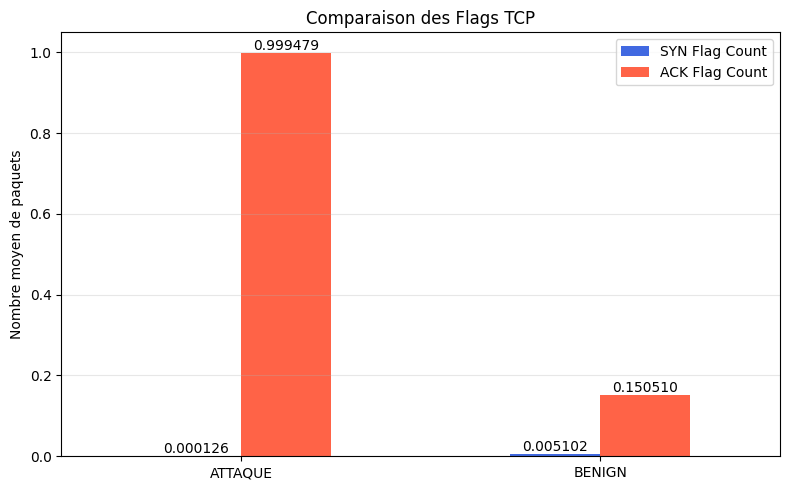

In [162]:
# BENIGN vs ATTAQUE
df['Classe'] = df['Label'].apply(lambda x: 'BENIGN' if x == 'BENIGN' else 'ATTAQUE')

# Calculer les moyennes directement
stats = df.groupby('Classe')[['SYN Flag Count', 'ACK Flag Count']].mean()
print(stats)
print(stats)
# Graphique
ax = stats.plot(kind='bar',figsize=(8,5),color=['royalblue', 'tomato'])
plt.title("Comparaison des Flags TCP")
plt.ylabel("Nombre moyen de paquets")
plt.xlabel("")
plt.xticks(rotation=0)
# Valeurs sur les barres
for container in ax.containers:
    ax.bar_label(container, fmt='%.6f')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# analyse de la variable Ratio_SYN_ACK dans chaque classe (syn et benign)

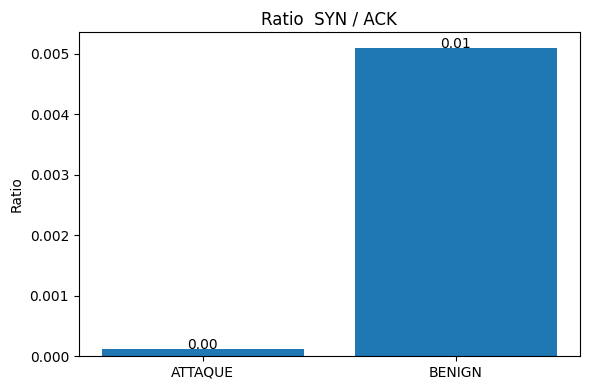

In [163]:
df['Ratio_SYN_ACK'] = (df['SYN Flag Count']/(df['ACK Flag Count'] + 1))
ratio = df.groupby('Classe')['Ratio_SYN_ACK'].mean()
plt.figure(figsize=(6,4))
bars = plt.bar(ratio.index,ratio.values)
plt.title("Ratio  SYN / ACK")
plt.ylabel("Ratio")

for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.2f}",
        ha='center'
    )

plt.tight_layout()
plt.show()

# FLOW DURATION L'analyse de la durée des flux (Flow Duration)

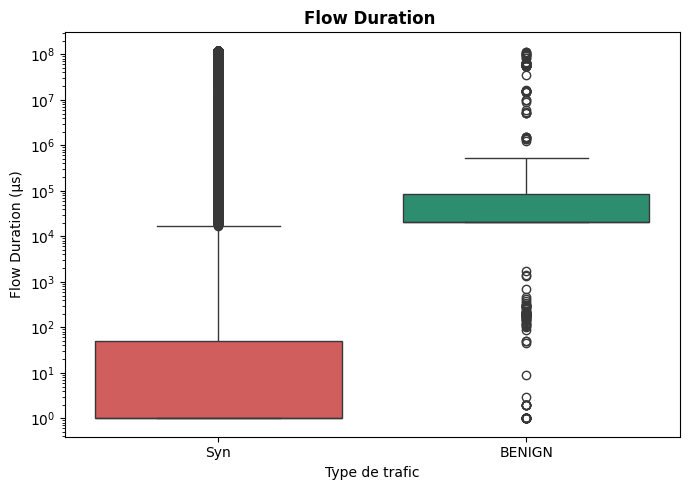

In [164]:

fig, ax = plt.subplots(figsize=(7, 5))
data = df[df['Flow Duration'] > 0]

ax.set_yscale('log')
sns.boxplot(data=data, x='Label', y='Flow Duration',
            order=['Syn', 'BENIGN'],  
            palette={'Syn': '#E24B4A', 'BENIGN': '#1D9E75'}, ax=ax)

ax.set_title('Flow Duration ', fontweight='bold')
ax.set_ylabel('Flow Duration (µs)')
ax.set_xlabel('Type de trafic')
plt.tight_layout()
plt.show()

# Analyse de flow bytes/s dans les deux classes

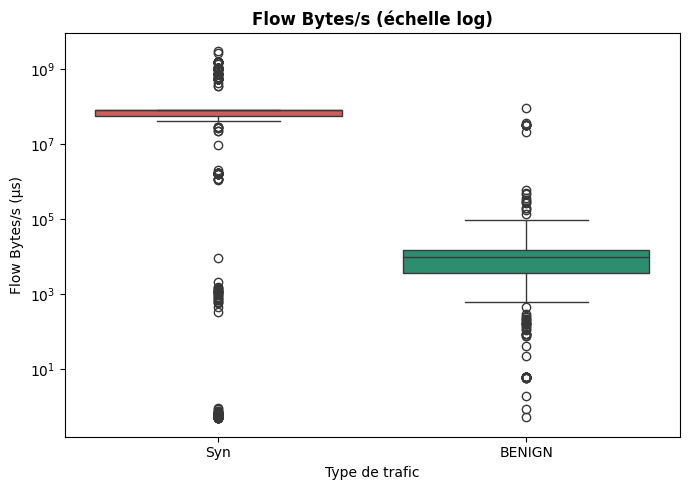

In [165]:

fig, ax = plt.subplots(figsize=(7, 5))
data = df[df['Flow Bytes/s'] > 0]

ax.set_yscale('log')
sns.boxplot(data=data, x='Label', y='Flow Bytes/s',
            order=['Syn', 'BENIGN'],  
            palette={'Syn': '#E24B4A', 'BENIGN': '#1D9E75'}, ax=ax)

ax.set_title('Flow Bytes/s (échelle log)', fontweight='bold')
ax.set_ylabel('Flow Bytes/s (µs)')
ax.set_xlabel('Type de trafic')
plt.tight_layout()
plt.show()

#  RATIO DOWN/UP : mesure le rapport entr le trafic recu et lr trafic envoyer(montante)

In [166]:
print(df.groupby('Classe')['Down/Up Ratio'].value_counts().sort_index())

Classe   Down/Up Ratio
ATTAQUE  0.00             1432503
         1.00              149746
         2.00                  31
         3.00                   8
         4.00                   1
BENIGN   0.00                 127
         1.00                 201
         2.00                  43
         3.00                  18
         4.00                   1
         5.00                   1
         7.00                   1
Name: count, dtype: int64


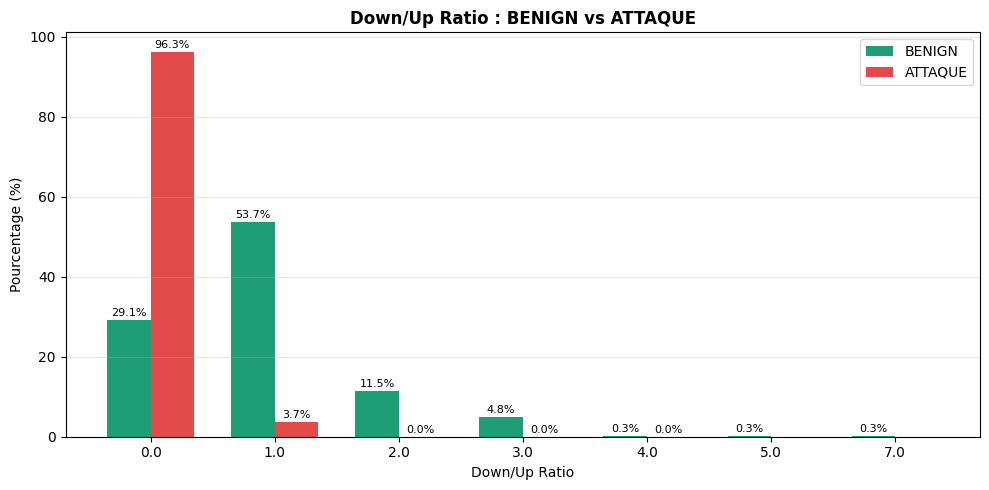

In [167]:
#Donnee
data = {
    'Classe': [0,0,0,0,0,0,0, 1,1,1,1,1],
    'Ratio': [0.0,1.0,2.0,3.0,4.0,5.0,7.0, 0.0,1.0,2.0,3.0,4.0],
    'Count': [109,201,43,18,1,1,1, 149717,5744,31,8,1]
}

df = pd.DataFrame(data)
df['Classe'] = df['Classe'].map({0: 'BENIGN', 1: 'ATTAQUE'})
df['Pct'] = df.groupby('Classe')['Count'].transform(lambda x: x / x.sum() * 100)

#  Pivoter
pivot = df.pivot_table(index='Ratio', columns='Classe', values='Pct', fill_value=0)

#  Graphique
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(len(pivot.index))
width = 0.35
ax.bar(x - width/2, pivot['BENIGN'], width, label='BENIGN', color='#1D9E75')
ax.bar(x + width/2, pivot['ATTAQUE'], width, label='ATTAQUE', color='#E24B4A')
ax.set_title('Down/Up Ratio : BENIGN vs ATTAQUE', fontweight='bold')
ax.set_xlabel('Down/Up Ratio')
ax.set_ylabel('Pourcentage (%)')
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Valeurs
for i, ratio in enumerate(pivot.index):
    v1 = pivot.loc[ratio, 'BENIGN']
    v2 = pivot.loc[ratio, 'ATTAQUE']
    if v1 > 0:
        ax.text(i - width/2, v1 + 0.5, f'{v1:.1f}%', ha='center', va='bottom', fontsize=8)
    if v2 > 0:
        ax.text(i + width/2, v2 + 0.5, f'{v2:.1f}%', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

##  Nettoyage des données (Gestion des valeurs manquantes, nulles et infinies)

In [175]:
# analyse des valeurs infinies
np.isinf(df.select_dtypes(include=np.number)).values.sum()

np.int64(202357)

In [176]:
# 1. Compter les inf par colonne
inf_col = np.isinf(df.select_dtypes(include=np.number)).sum()
print(inf_col[inf_col > 0])

Flow Bytes/s          40
Flow Packets/s    202317
dtype: int64


In [177]:
# Afficher les lignes dnt on a des valeur inf dans flow bytes 
lignes_inf = df[np.isinf(df['Flow Bytes/s'])].head(1)
lignes_inf[['Flow Duration', 'Total Fwd Packets', 'Flow Bytes/s', 'Label']].style

,Flow Duration,Total Fwd Packets,Flow Bytes/s,Label
506,0,2,inf,Syn


In [178]:
# Afficher les 5 premières lignes avec inf dans Flow Packets/s
lignes_inf = df[np.isinf(df['Flow Packets/s'])].head(1)
lignes_inf[['Flow Duration', 'Total Fwd Packets', 'Flow Packets/s', 'Label']].style

,Flow Duration,Total Fwd Packets,Flow Packets/s,Label
3,0,2,inf,Syn


In [179]:
# nbre de valeurs maquantes
df.isna().sum().sum()

np.int64(202277)

In [ ]:
# Afficher les colonnes qui ont des NaN
print(df.columns[df.isna().any()].tolist())
# Afficher 3 lignes avec NaN dans 'Flow Bytes/s' a
df[df['Flow Bytes/s'].isna()][['Flow Duration', 'Flow Bytes/s', 'Label']].head(3).style

['Flow Bytes/s']


,Flow Duration,Flow Bytes/s,Label
3,0,nan,Syn
6,0,nan,Syn
12,0,nan,Syn


In [180]:
# Nombre total de lignes dupliquées
nb_duplicates = df.duplicated().sum()
print(f"Nombre de lignes dupliquées : {nb_duplicates}")

# Pourcentage de doublons
pct_duplicates = (nb_duplicates / len(df)) * 100
print(f"Pourcentage de doublons : {pct_duplicates:.2f}%")

Nombre de lignes dupliquées : 1426789
Pourcentage de doublons : 90.15%


In [ ]:
#df[df.duplicated(keep=False)].head(4)

In [181]:
df.dropna(inplace=True)
df[df.duplicated(keep=False)].head(2)

,Protocol,Flow Duration,Total Fwd Packets,Total Backward Packets,Fwd Packets Length Total,Bwd Packets Length Total,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,Fwd Seg Size Min,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,6,1,2,0,0.00,0.00,0.00,0.00,0.00,0.00,...,20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Syn
1,6,1,2,0,0.00,0.00,0.00,0.00,0.00,0.00,...,20,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,Syn


In [182]:
df.drop_duplicates(inplace=True)

In [183]:
df.reset_index(inplace=True, drop=True)

In [184]:
df.shape

(155886, 66)

In [185]:
# Exclure les colonnes cibles
feature_cols = [col for col in df.columns if col not in ['Label']]
X = df[feature_cols]
y = df['Label']


# split train test

In [186]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"X_train : {X_train.shape}")
print(f"X_test  : {X_test.shape}")

X_train : (124708, 65)
X_test  : (31178, 65)


# encodage

In [187]:
le_y = LabelEncoder()

y_train = le_y.fit_transform(y_train)
y_test = le_y.transform(y_test)

Analyse Exploratoire des Données :Exploratory Data Analysis (EDA)

In [188]:
X = pd.DataFrame(X, columns=feature_cols)
cat_columns = ["Protocol", "Fwd PSH Flags", "SYN Flag Count", "ACK Flag Count", "URG Flag Count","CWE Flag Count"]
num_columns = [col for col in X.columns if col not in cat_columns]

# Convertir les colonnes numériques en float32
for col in num_columns:
    X_train[col] = X_train[col].astype('float32')
    X_test[col] = X_test[col].astype('float32')

# Encoder les colonnes catégorielles
le = LabelEncoder()
for col in cat_columns:
    le = LabelEncoder()
    # Fit sur TRAIN seulement
    X_train[col] = le.fit_transform(X_train[col].astype(str))
    # Transform sur TEST
    X_test[col] = le.transform(X_test[col].astype(str))
    # Convertir en int32
    X_train[col] = X_train[col].astype('int32')
    X_test[col] = X_test[col].astype('int32')


In [189]:
train_df = X_train.copy()
test_df = X_test.copy()
train_df['Label'] = y_train
test_df['Label'] = y_test

# Appliquer la corrélation
numerical_df = train_df.select_dtypes(include=[np.number])
corr_matrix = numerical_df.corr().abs()

mask = np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
upper_triangle = corr_matrix.where(mask)

high_corr_cols = [col for col in upper_triangle.columns if any(upper_triangle[col] > 0.8)]

if 'Label' in high_corr_cols:
    high_corr_cols.remove('Label')

print(f"Colonnes corrélées : {len(high_corr_cols)}")
print(high_corr_cols)

# Supprimer
train_df = train_df.drop(columns=high_corr_cols)
test_df = test_df.drop(columns=high_corr_cols)

# Récupérer X et y
X_train = train_df.drop('Label', axis=1)
y_train = train_df['Label']
X_test = test_df.drop('Label', axis=1)
y_test = test_df['Label']

print(f"\n Final : X_train {X_train.shape}, X_test {X_test.shape}")

Colonnes corrélées : 37
['Bwd Packets Length Total', 'Fwd Packet Length Mean', 'Fwd Packet Length Std', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s', 'Flow IAT Std', 'Flow IAT Max', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max', 'Bwd IAT Mean', 'Bwd IAT Std', 'Bwd IAT Max', 'Fwd Header Length', 'Bwd Header Length', 'Fwd Packets/s', 'Packet Length Min', 'Packet Length Max', 'Packet Length Mean', 'Packet Length Std', 'Packet Length Variance', 'RST Flag Count', 'Avg Packet Size', 'Avg Fwd Segment Size', 'Avg Bwd Segment Size', 'Subflow Fwd Packets', 'Subflow Fwd Bytes', 'Subflow Bwd Packets', 'Subflow Bwd Bytes', 'Active Std', 'Active Max', 'Idle Mean', 'Idle Std', 'Idle Max', 'Idle Min']

 Final : X_train (124708, 28), X_test (31178, 28)


In [190]:
X_train.info()

<class 'pandas.DataFrame'>
Index: 124708 entries, 122114 to 14240
Data columns (total 28 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   Protocol                  124708 non-null  int32  
 1   Flow Duration             124708 non-null  float32
 2   Total Fwd Packets         124708 non-null  float32
 3   Total Backward Packets    124708 non-null  float32
 4   Fwd Packets Length Total  124708 non-null  float32
 5   Fwd Packet Length Max     124708 non-null  float32
 6   Fwd Packet Length Min     124708 non-null  float32
 7   Bwd Packet Length Max     124708 non-null  float32
 8   Bwd Packet Length Min     124708 non-null  float32
 9   Flow Packets/s            124708 non-null  float32
 10  Flow IAT Mean             124708 non-null  float32
 11  Flow IAT Min              124708 non-null  float32
 12  Fwd IAT Min               124708 non-null  float32
 13  Bwd IAT Total             124708 non-null  float32
 14  

In [191]:
def evaluer_modele(nom_modele, y_test, y_pred):
    
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f" RÉSULTATS {nom_modele.upper()}")

    print("\nClassification Report :")
    print(classification_report(y_test, y_pred, target_names=['BENIGN', 'Attaque'], digits=6))
    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['BENIGN', 'Attaque'], 
            yticklabels=['BENIGN', 'Attaque'])
    plt.title('Matrice de confusion ')
    plt.xlabel('Prédit')
    plt.ylabel('Réel')
    plt.tight_layout()
    plt.show()
    
    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1_score': f1}

In [193]:
##  Remplacer les infinis par NaN 
X_train = X_train.replace([np.inf, -np.inf], np.nan)
X_test = X_test.replace([np.inf, -np.inf], np.nan)

 RÉSULTATS RANDOM FOREST

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.987013  1.000000  0.993464        76
     Attaque   1.000000  0.999968  0.999984     31102

    accuracy                       0.999968     31178
   macro avg   0.993506  0.999984  0.996724     31178
weighted avg   0.999968  0.999968  0.999968     31178



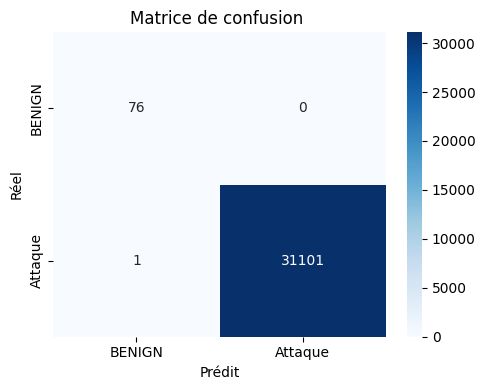

{'accuracy': 0.9999679261017385,
 'precision': 0.9999683426458716,
 'recall': 0.9999679261017385,
 'f1_score': 0.9999680306605832}

In [194]:
##Random Forest 
# Entraînement du modèle
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Prédictions
y_pred = model.predict(X_test)
# Évaluation 
evaluer_modele('Random Forest', y_test, y_pred)

 RÉSULTATS XGBCLASSIFIER

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.974359  0.987013  0.980645        77
     Attaque   0.999968  0.999936  0.999952     31102

    accuracy                       0.999904     31179
   macro avg   0.987163  0.993474  0.990298     31179
weighted avg   0.999905  0.999904  0.999904     31179



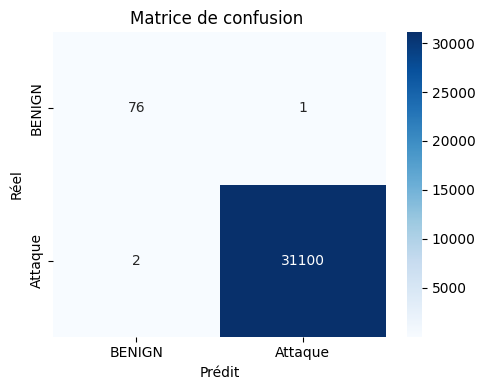

{'accuracy': 0.9999037813913211,
 'precision': 0.999904602741343,
 'recall': 0.9999037813913211,
 'f1_score': 0.9999040910005055}

In [ ]:
# XGBoost 
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
# 6. Évaluation
y_pred = model.predict(X_test)
# Évaluation 
evaluer_modele('XGBClassifier', y_test, y_pred)

 RÉSULTATS EXTRA TREES

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.974359  0.987013  0.980645        77
     Attaque   0.999968  0.999936  0.999952     31102

    accuracy                       0.999904     31179
   macro avg   0.987163  0.993474  0.990298     31179
weighted avg   0.999905  0.999904  0.999904     31179



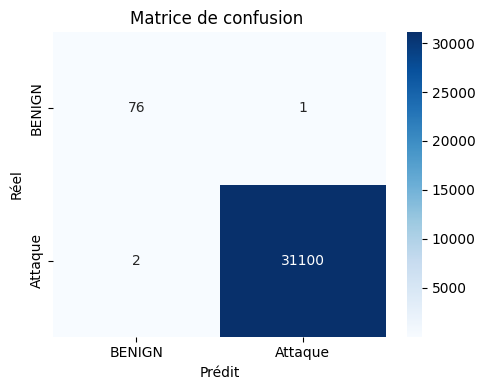

{'accuracy': 0.9999037813913211,
 'precision': 0.999904602741343,
 'recall': 0.9999037813913211,
 'f1_score': 0.9999040910005055}

In [ ]:
# ExtraTreesClassifier
model = ExtraTreesClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluer_modele('Extra Trees', y_test, y_pred)

In [ ]:
# Imputer les NAN
# Analyse du describ
pd.set_option('display.float_format', '{:.2f}'.format)
df = df.replace([np.inf, -np.inf], np.nan)
# Grouper par Label et décrire les 2 colonnes
result = df.groupby('Label')[['Flow Bytes/s', 'Flow Packets/s']].describe().T
print(result)

Label                     BENIGN           Syn
Flow Bytes/s   count      374.00     155501.00
               mean    990886.20      92079.00
               std    6577609.37   12487751.12
               min          0.00          0.00
               25%          0.00          0.00
               50%       5493.19          0.00
               75%      12539.98          0.00
               max   89333333.33 2944000000.00
Flow Packets/s count      374.00     155501.00
               mean    161030.25       2344.24
               std     565555.22      29544.99
               min          0.07          0.03
               25%         54.67          0.14
               50%        191.36          0.16
               75%        218.47          0.19
               max    3000000.00    2000000.00


In [195]:
# 2. Imputer les NaN (remplacer par la médiane)
from sklearn.impute import SimpleImputer

#cols = ['Flow Bytes/s', 'Flow Packets/s']
#df[cols] = df[cols].fillna(df[cols].median())

imputer = SimpleImputer(strategy='median')
X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

## # Déséquilibre des Classes, Mise à l'Échelle, Extraction de Features

In [196]:
# Version simplifiée
def distrib_classes(y):
    unique, counts = np.unique(y, return_counts=True)
    for label, count in zip(unique, counts):
        print(f"Classe {label} : {count:,} ({count/len(y)*100:.2f}%)")

print("Avant split :")
distrib_classes(y)
print("\nTrain :")
distrib_classes(y_train)
print("\nTest :")
distrib_classes(y_test)

Avant split :
Classe BENIGN : 382 (0.25%)
Classe Syn : 155,504 (99.75%)

Train :
Classe 0 : 306 (0.25%)
Classe 1 : 124,402 (99.75%)

Test :
Classe 0 : 76 (0.24%)
Classe 1 : 31,102 (99.76%)


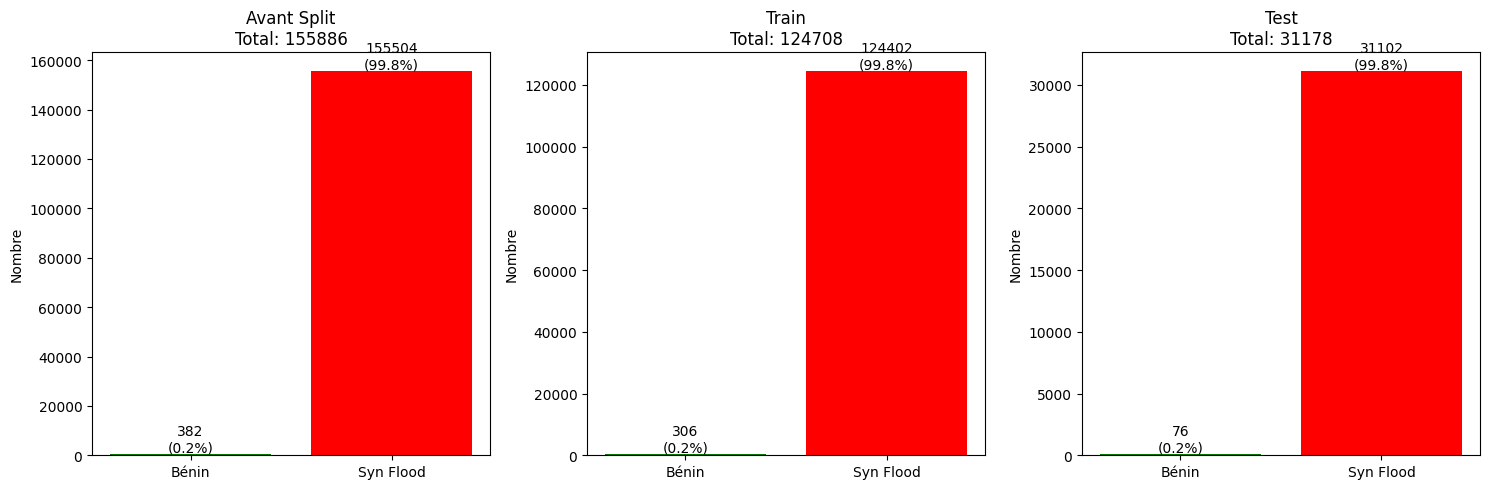

In [197]:
import matplotlib.pyplot as plt
import numpy as np

# Créer la figure avec 3 sous-graphiques
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Données
datasets = [
    (y, 'Avant Split'),
    (y_train, 'Train'),
    (y_test, 'Test')
]

# Pour chaque dataset
for i, (data, title) in enumerate(datasets):
    # Compter les classes
    unique, counts = np.unique(data, return_counts=True)
    
    # Créer le diagramme
    bars = axes[i].bar(['Bénin', 'Syn Flood'], counts, color=['green', 'red'])
    
    # Ajouter les chiffres sur les barres
    for bar, count in zip(bars, counts):
        axes[i].text(bar.get_x() + bar.get_width()/2, 
                    bar.get_height() + 5,
                    f'{count}\n({count/len(data)*100:.1f}%)',
                    ha='center', va='bottom')
    
    # Titre
    axes[i].set_title(f'{title}\nTotal: {len(data)}')
    axes[i].set_ylabel('Nombre')

# Afficher
plt.tight_layout()
plt.show()

In [198]:
# SMOTE qui génère des données synthétiques
from imblearn.over_sampling import SMOTE
print(f"Distribution avant smote: {dict(pd.Series(y_train).value_counts())}")
smote = SMOTE(random_state=42)
X_train, y_train = smote.fit_resample(X_train, y_train)
# verication apres smote sur X_train
print(f"Distribution apres smote: {dict(pd.Series(y_train).value_counts())}")


Distribution avant smote: {1: np.int64(124402), 0: np.int64(306)}
Distribution apres smote: {1: np.int64(124402), 0: np.int64(124402)}


In [ ]:
### Normalisation 
scaler = StandardScaler()
#X_train = scaler.fit_transform(X_train)
#X_test = scaler.transform(X_test)

In [ ]:
#sauvegarde l'état
import joblib
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

 RÉSULTATS RANDOM FOREST

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.987013  1.000000  0.993464        76
     Attaque   1.000000  0.999968  0.999984     31102

    accuracy                       0.999968     31178
   macro avg   0.993506  0.999984  0.996724     31178
weighted avg   0.999968  0.999968  0.999968     31178



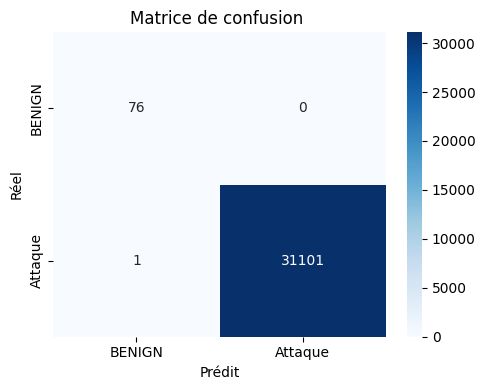

{'accuracy': 0.9999679261017385,
 'precision': 0.9999683426458716,
 'recall': 0.9999679261017385,
 'f1_score': 0.9999680306605832}

In [199]:
##Random Forest apres avoir fait imputation et smote
# Entraînement du modèle a nouveau
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
# Prédictions
y_pred = model.predict(X_test)
# Évaluation 
evaluer_modele('Random Forest', y_test, y_pred)

 RÉSULTATS XGBCLASSIFIER

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.950617  1.000000  0.974684        77
     Attaque   1.000000  0.999871  0.999936     31102

    accuracy                       0.999872     31179
   macro avg   0.975309  0.999936  0.987310     31179
weighted avg   0.999878  0.999872  0.999873     31179



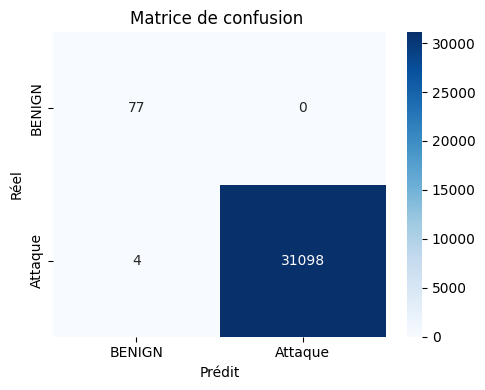

{'accuracy': 0.9998717085217614,
 'precision': 0.9998780439034028,
 'recall': 0.9998717085217614,
 'f1_score': 0.999873328339396}

In [ ]:
# XGBoost 
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=6,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)
# 6. Évaluation
y_pred = model.predict(X_test)
# Évaluation 
evaluer_modele('XGBClassifier', y_test, y_pred)

 RÉSULTATS EXTRA TREES

Classification Report :
              precision    recall  f1-score   support

      BENIGN   0.950617  1.000000  0.974684        77
     Attaque   1.000000  0.999871  0.999936     31102

    accuracy                       0.999872     31179
   macro avg   0.975309  0.999936  0.987310     31179
weighted avg   0.999878  0.999872  0.999873     31179



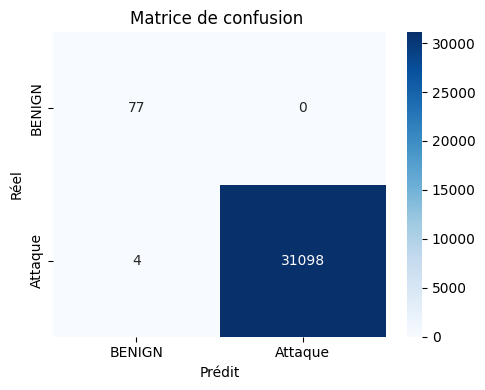

{'accuracy': 0.9998717085217614,
 'precision': 0.9998780439034028,
 'recall': 0.9998717085217614,
 'f1_score': 0.999873328339396}

In [ ]:
# ExtraTreesClassifier
model = ExtraTreesClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
evaluer_modele('Extra Trees', y_test, y_pred)

### SÉLECTION DE FEATURES : Random Forest

 TOP 20 FEATURES - RANDOM FOREST
 1. ACK Flag Count                 : 0.195701 (19.57%)
 2. Flow IAT Mean                  : 0.109145 (10.91%)
 3. Fwd IAT Mean                   : 0.057243 (5.72%)
 4. Idle Std                       : 0.055257 (5.53%)
 5. Fwd IAT Total                  : 0.054042 (5.40%)
 6. Packet Length Variance         : 0.052451 (5.25%)
 7. Total Length of Fwd Packets    : 0.042675 (4.27%)
 8. Bwd Packets/s                  : 0.040543 (4.05%)
 9. Fwd Packet Length Max          : 0.030357 (3.04%)
10. Avg Fwd Segment Size           : 0.030304 (3.03%)
11. Packet Length Mean             : 0.029804 (2.98%)
12. Flow Duration                  : 0.028049 (2.80%)
13. URG Flag Count                 : 0.027990 (2.80%)
14. Max Packet Length              : 0.027903 (2.79%)
15. Init_Win_bytes_backward        : 0.025418 (2.54%)
16. Init_Win_bytes_forward         : 0.023186 (2.32%)
17. Average Packet Size            : 0.021836 (2.18%)
18. Fwd IAT Max                    : 0.017797 (

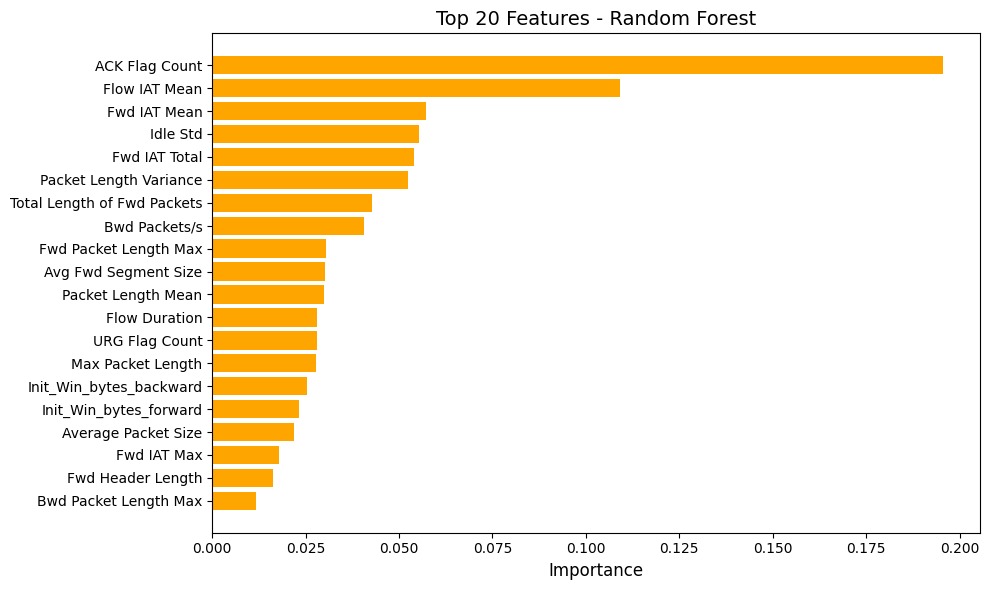

In [ ]:
rf = RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42)
rf.fit(X_train, y_train)

#  Récupérer les importances
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]
features = X_train.columns[indices]


#  Afficher les valeurs
print(" TOP 20 FEATURES - RANDOM FOREST")

for i, (feature, importance) in enumerate(zip(features, importances[indices])):
    print(f"{i+1:2d}. {feature:30} : {importance:.6f} ({importance*100:.2f}%)")

# 4. Graphique
plt.figure(figsize=(10, 6))
plt.barh(features[::-1], importances[indices[::-1]], color='orange')
plt.title("Top 20 Features - Random Forest", fontsize=14)
plt.xlabel("Importance", fontsize=12)
plt.tight_layout()
plt.show()

In [ ]:
import joblib
# Sauvegarder les features sélectionnées
meilleures_features_rf = X_train.columns[indices].tolist()
joblib.dump(meilleures_features_rf, 'features_selectionnees.pkl')


['features_selectionnees.pkl']

In [ ]:
X_train = X_train[meilleures_features_rf]
X_test = X_test[meilleures_features_rf]
X_train.shape

(248802, 20)

In [ ]:
scaler_20 = StandardScaler()
scaler_20.fit(X_train)

joblib.dump(scaler_20, 'scaler_20.pkl')

['scaler_20.pkl']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# 1. Préparer les données
# ============================================

data = {
    'Classe': [0,0,0,0,0,0,0, 1,1,1,1,1],
    'Down/Up Ratio': [0.0,1.0,2.0,3.0,4.0,5.0,7.0, 0.0,1.0,2.0,3.0,4.0],
    'Count': [109,201,43,18,1,1,1, 149717,5744,31,8,1]
}

df_plot = pd.DataFrame(data)

# Ajouter les pourcentages par classe
df_plot['Classe'] = df_plot['Classe'].map({0: 'BENIGN', 1: 'ATTAQUE'})
df_plot['Pct'] = df_plot.groupby('Classe')['Count'].transform(lambda x: x / x.sum() * 100)

# ============================================
# 2. Tableau des pourcentages (comparaison)
# ============================================

print("="*60)
print(" TABLEAU COMPARATIF : DOWN/UP RATIO")
print("="*60)

# Créer un tableau pivot pour l'affichage
tableau = df_plot.pivot_table(index='Down/Up Ratio', columns='Classe', values=['Count', 'Pct'], fill_value=0)

# Afficher le tableau
print("\n📊 Comparaison des effectifs et pourcentages :")
print("-"*50)

for ratio in sorted(df_plot['Down/Up Ratio'].unique()):
    row = df_plot[df_plot['Down/Up Ratio'] == ratio]
    benign = row[row['Classe'] == 'BENIGN']
    attaque = row[row['Classe'] == 'ATTAQUE']
    
    count_b = benign['Count'].values[0] if len(benign) > 0 else 0
    count_a = attaque['Count'].values[0] if len(attaque) > 0 else 0
    pct_b = benign['Pct'].values[0] if len(benign) > 0 else 0
    pct_a = attaque['Pct'].values[0] if len(attaque) > 0 else 0
    
    print(f"Ratio {ratio:.1f} :")
    print(f"   BENIGN  : {count_b:>8,} ({pct_b:>6.2f}%)")
    print(f"   ATTAQUE : {count_a:>8,} ({pct_a:>6.2f}%)")
    print()

# ============================================
# 3. Pivoter les données pour barres côte à côte
# ============================================

pivot = df_plot.pivot_table(index='Down/Up Ratio', columns='Classe', values='Pct', fill_value=0)

# ============================================
# 4. Diagramme barres côte à côte
# ============================================

fig, ax = plt.subplots(figsize=(12, 6))

width = 0.35
x = np.arange(len(pivot.index))

# Barres côte à côte
ax.bar(x - width/2, pivot['BENIGN'], width, label='BENIGN', color='#1D9E75', edgecolor='black')
ax.bar(x + width/2, pivot['ATTAQUE'], width, label='ATTAQUE', color='#E24B4A', edgecolor='black')

# Personnalisation
ax.set_title('Down/Up Ratio : BENIGN vs ATTAQUE (pourcentage par classe)', 
             fontweight='bold', fontsize=14)
ax.set_xlabel('Down/Up Ratio', fontsize=12)
ax.set_ylabel('Pourcentage (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(pivot.index)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

# Ajouter les valeurs sur les barres
for i, ratio in enumerate(pivot.index):
    # BENIGN
    val_benign = pivot.loc[ratio, 'BENIGN']
    if val_benign > 0:
        ax.text(i - width/2, val_benign + 0.5, f'{val_benign:.1f}%', 
                ha='center', va='bottom', fontsize=8)
    
    # ATTAQUE
    val_attaque = pivot.loc[ratio, 'ATTAQUE']
    if val_attaque > 0:
        ax.text(i + width/2, val_attaque + 0.5, f'{val_attaque:.1f}%', 
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()